# Unsupervised classification

In this notebook we will use embeddings to develop an unsupervised classification of areas in London in 2024.

## Embeddings classification

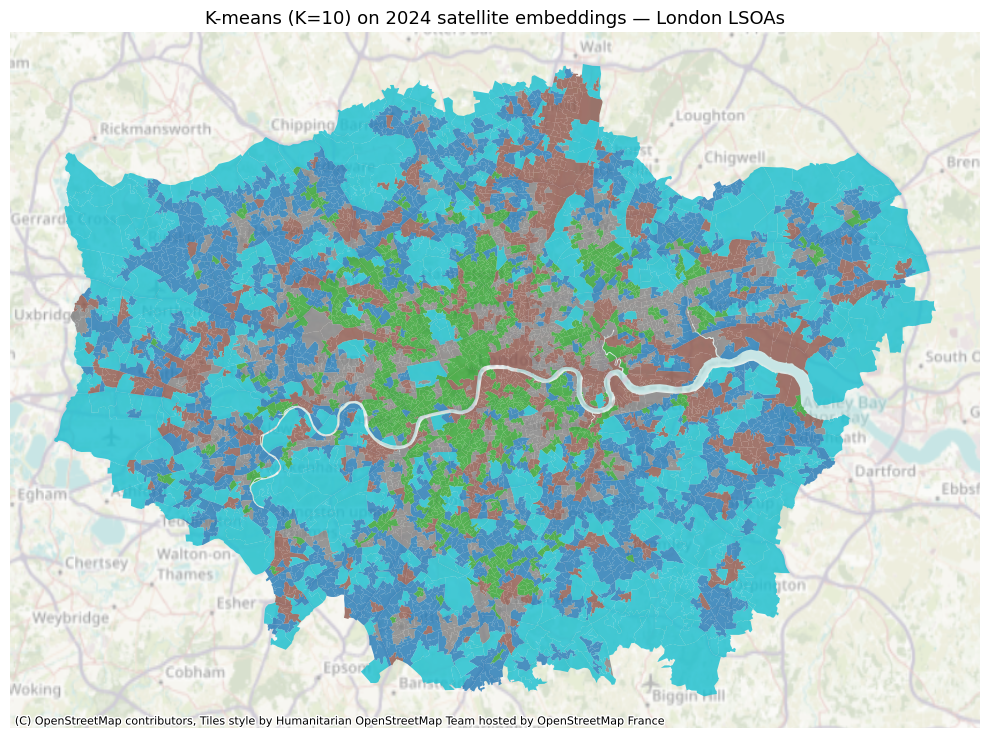

In [22]:
import geopandas
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from sklearn.cluster import KMeans

# Load 2024 embeddings (geometry included for mapping)
emb24 = geopandas.read_file('uk_lsoa_london_embeds_2024.geojson')
emb_cols = [c for c in emb24.columns if c.endswith('_mean')]

# K-means, K=10
km = KMeans(n_clusters=5, random_state=42, n_init='auto')
emb24 = emb24.assign(cluster=km.fit_predict(emb24[emb_cols].values))

# Map
fig, ax = plt.subplots(figsize=(10, 10))
emb24.plot(column='cluster', cmap='tab10', ax=ax, linewidth=0, alpha=0.8)
cx.add_basemap(ax, crs=emb24.crs, alpha=0.5)
ax.set_axis_off()
ax.set_title('K-means (K=10) on 2024 satellite embeddings — London LSOAs', fontsize=13)
plt.tight_layout()
plt.show()


## Comparison with Urban Atlas

In this section, we compare the embedding based classification with the Urban Atlas for 2021. Specifically:

- Read file
- Aggregate Urban Atlas classes at the LSOA geography (we compute proportions of each LSOA area for each Urban Atlas), providing a `DataFrame` with all the LSOAs in `emb24`, one column for each Urban Atlas class that contains the proportion of the LSOA covered by that class, and an additional column with the area (in case we later want to switch to total areas rather than proportions).
- Compare both datasets: we build a double-entry table where the rows contain all the embedding-based classes and the columns include all the Urban Atlas classes. The values in each cell reflect co-location: how much (proportion in one table, and total area) of a given embedding-based class is shared with a given Urban Atlas class.

### Read Urban Atlas

We load the 2021 Urban Atlas from the nested zip directly into memory, keeping only the land use class columns and geometry.


In [9]:
import zipfile, io

outer = zipfile.ZipFile('src_data/74956.zip')
inner_bytes = outer.read(
    'Results/CLMS_UA_LCU_S2021_V025ha_UK001L3_LONDON_03035_V01_R01_20250730.zip'
)
inner = zipfile.ZipFile(io.BytesIO(inner_bytes))
fgb_name = next(n for n in inner.namelist() if n.endswith('.fgb'))

with inner.open(fgb_name) as f:
    ua = geopandas.read_file(f)[['code_2021', 'class_2021', 'geometry']]

print(f"{len(ua):,} polygons, {ua['class_2021'].nunique()} classes")
ua['class_2021'].value_counts()


133,772 polygons, 27 classes


class_2021
Discontinuous dense urban fabric (S.L. : 50% -  80%)                               31339
Industrial, commercial, public, military and private units                         20781
Discontinuous medium density urban fabric (S.L. : 30% - 50%)                       16685
Pastures                                                                           12158
Discontinuous low density urban fabric (S.L. : 10% - 30%)                           8929
Arable land (annual crops)                                                          8509
Forests                                                                             7550
Continuous urban fabric (S.L. : > 80%)                                              5515
Isolated structures                                                                 5492
Sports and leisure facilities                                                       4591
Green urban areas (Public access)                                                   4489
Discontinu

### Aggregate to LSOAs

We intersect the Urban Atlas polygons with the LSOA boundaries (reprojecting to EPSG:3035 for area calculations), then compute for each LSOA the proportion of its area covered by each Urban Atlas class.


In [10]:
# Reproject LSOAs to EPSG:3035 to match Urban Atlas
lsoas = emb24[['LSOA21CD', 'geometry']].to_crs(3035)
lsoas = lsoas.assign(lsoa_area=lsoas.geometry.area)

# Spatial intersection
ix = lsoas.overlay(ua, how='intersection')
ix = ix.assign(int_area=ix.geometry.area)

# Proportion of each UA class within each LSOA
lsoa_ua = (
    ix.groupby(['LSOA21CD', 'class_2021'])['int_area'].sum()
    .reset_index()
    .merge(lsoas[['LSOA21CD', 'lsoa_area']], on='LSOA21CD')
    .assign(proportion=lambda d: d['int_area'] / d['lsoa_area'])
)

# Wide form: one row per LSOA, one column per UA class
ua_wide = (
    lsoa_ua
    .pivot_table(index='LSOA21CD', columns='class_2021',
                 values='proportion', fill_value=0)
)
ua_wide.columns.name = None
print(ua_wide.shape)
ua_wide.head()


(4951, 27)


,Airports,Arable land (annual crops),Construction sites,Continuous urban fabric (S.L. : > 80%),Discontinuous dense urban fabric (S.L. : 50% - 80%),Discontinuous low density urban fabric (S.L. : 10% - 30%),Discontinuous medium density urban fabric (S.L. : 30% - 50%),Discontinuous very low density urban fabric (S.L. : < 10%),Fast transit roads and associated land,Forests,...,Mineral extraction and dump sites,"Open spaces with little or no vegetation (beaches, dunes, bare rocks, glaciers)",Other roads and associated land,Pastures,"Permanent crops (vineyards, fruit trees, olive groves)",Port areas,Railways and associated land,Sports and leisure facilities,Water,Wetlands
LSOA21CD,,,,,,,,,,,,,,,,,,,,,
E01000001,0.0,0.0,0.0,0.031055,0.176915,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.194998,0.0,0.0,0.0,0.006305,0.0,0.0,0.0
E01000002,0.0,0.0,0.0,0.262830,0.218067,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.148329,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
E01000003,0.0,0.0,0.0,0.799684,0.007865,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.156577,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
E01000005,0.0,0.0,0.0,0.670766,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.196948,0.0,0.0,0.0,0.019146,0.0,0.0,0.0
E01000006,0.0,0.0,0.0,0.000000,0.655491,0.0,0.087154,0.0,0.0,0.0,...,0.0,0.0,0.109877,0.0,0.0,0.0,0.146987,0.0,0.0,0.0


### Cross-tabulation

Two double-entry tables with embedding clusters as rows and Urban Atlas classes as columns: one showing the mean proportion of each LSOA's area covered by each class, one showing total area in km².


In [23]:
import pandas
from IPython.display import display

cluster_labels = emb24.set_index('LSOA21CD')['cluster']
ua_clustered = ua_wide.join(cluster_labels)
ua_cols = [c for c in ua_clustered.columns if c != 'cluster']

# Mean proportion of each UA class per cluster
prop_tbl = ua_clustered.groupby('cluster')[ua_cols].mean().round(3)

# Total area (km²) of each UA class per cluster
area_tbl = (
    lsoa_ua
    .merge(cluster_labels.rename('cluster'), left_on='LSOA21CD', right_index=True)
    .groupby(['cluster', 'class_2021'])['int_area'].sum()
    .unstack(fill_value=0)
    .div(1e6)
    .round(2)
)
area_tbl.columns.name = None

style = dict(cmap='YlOrRd', axis=1)

print("Mean proportion of Urban Atlas class per cluster")
display(prop_tbl.T.style.background_gradient(**style).format('{:.3f}'))

print("\nTotal area by Urban Atlas class per cluster (km²)")
display(area_tbl.T.style.background_gradient(**style).format('{:.2f}'))


Mean proportion of Urban Atlas class per cluster


cluster,0,1,2,3,4
Airports,0.000,0.000,0.000,0.000,0.003
Arable land (annual crops),0.001,0.000,0.002,0.000,0.032
Construction sites,0.001,0.001,0.004,0.001,0.001
Continuous urban fabric (S.L. : > 80%),0.005,0.116,0.071,0.102,0.003
Discontinuous dense urban fabric (S.L. : 50% - 80%),0.439,0.547,0.463,0.534,0.173
Discontinuous low density urban fabric (S.L. : 10% - 30%),0.018,0.002,0.007,0.002,0.024
Discontinuous medium density urban fabric (S.L. : 30% - 50%),0.214,0.038,0.095,0.054,0.154
Discontinuous very low density urban fabric (S.L. : < 10%),0.002,0.003,0.001,0.000,0.003
Fast transit roads and associated land,0.000,0.000,0.000,0.000,0.002
Forests,0.001,0.000,0.000,0.000,0.030



Total area by Urban Atlas class per cluster (km²)


cluster,0,1,2,3,4
Airports,0.00,0.00,0.50,0.00,13.67
Arable land (annual crops),0.87,0.00,1.13,0.09,40.42
Construction sites,0.78,0.16,1.47,0.15,1.04
Continuous urban fabric (S.L. : > 80%),1.77,14.38,9.11,10.86,0.85
Discontinuous dense urban fabric (S.L. : 50% - 80%),155.87,71.57,78.81,72.38,58.98
Discontinuous low density urban fabric (S.L. : 10% - 30%),8.39,0.21,1.82,0.23,13.65
Discontinuous medium density urban fabric (S.L. : 30% - 50%),92.32,5.94,20.93,9.63,70.79
Discontinuous very low density urban fabric (S.L. : < 10%),0.79,0.26,0.17,0.05,2.00
Fast transit roads and associated land,0.20,0.00,0.11,0.04,1.64
Forests,0.66,0.00,0.16,0.00,26.84


### UA class aggregation

The Urban Atlas dataset contains 27 distinct land-use classes. When spread across cluster-level cross-tabulations, most classes have a negligible footprint across London LSOAs, making the tables cluttered and hard to interpret.

We address this with hierarchical aggregation guided by a **1% mean-proportion threshold**. Classes whose mean LSOA proportion falls below 1% are merged with sibling classes that share the same three-digit UA hierarchy code (e.g., all classes under `111` — urban fabric variants). If the combined proportion of those siblings still falls short of 1%, they are elevated to the two-digit level. Any class or group that remains below 1% even at two digits is collapsed into a single "Other" bucket. Classes that individually exceed 1% are retained under their original name.

In [24]:
# Map each class to its UA code (zero-padded to 5 digits)
class_to_code = (
    ua[['class_2021', 'code_2021']].drop_duplicates()
    .set_index('class_2021')['code_2021']
    .astype(str).str.zfill(5)
)

mean_prop = ua_wide.mean().sort_values(ascending=False)
threshold = 0.01

small = mean_prop[mean_prop < threshold].index.tolist()
keep  = mean_prop[mean_prop >= threshold].index.tolist()

agg_map = {cls: cls for cls in keep}
for cls in small:
    code = class_to_code[cls]
    parent3 = code[:3]
    siblings3 = [c for c in small if class_to_code[c].startswith(parent3)]
    if mean_prop[siblings3].sum() >= threshold:
        agg_map[cls] = f'Other {parent3}xx'
        continue
    parent2 = code[:2]
    siblings2 = [c for c in small if class_to_code[c].startswith(parent2)]
    if mean_prop[siblings2].sum() >= threshold:
        agg_map[cls] = f'Other {parent2}xxx'
        continue
    agg_map[cls] = 'Other'

ua_wide_agg = ua_wide.T.groupby(agg_map).sum().T
print(f"UA classes: {ua_wide.shape[1]} → {ua_wide_agg.shape[1]}")

UA classes: 27 → 11


In [25]:
from IPython.display import display

# Aggregation decision table
summary = (
    pandas.DataFrame({
        'Original class': list(agg_map.keys()),
        'Aggregated to': list(agg_map.values()),
        'Mean proportion': mean_prop[list(agg_map.keys())].values,
    })
    .sort_values('Mean proportion', ascending=False)
    .reset_index(drop=True)
)
display(
    summary.style
    .format({'Mean proportion': '{:.3f}'})
    .apply(lambda row: ['background-color: #d4edda' if row['Original class'] == row['Aggregated to']
                        else 'background-color: #fff3cd' for _ in row], axis=1)
    .set_caption('UA class aggregation decisions (green = kept, yellow = aggregated)')
)

# For each aggregated UA class, what share of its total London area falls in each cluster?
lsoa_ua_agg = (
    lsoa_ua
    .assign(agg_class=lambda d: d['class_2021'].map(agg_map))
    .merge(cluster_labels.rename('cluster'), left_on='LSOA21CD', right_index=True)
)

cluster_class_area = (
    lsoa_ua_agg
    .groupby(['cluster', 'agg_class'])['int_area'].sum()
    .unstack(fill_value=0)
)
cluster_class_area.columns.name = None

# Column-normalise: fraction of each UA class's total area per cluster
share_tbl = cluster_class_area.div(cluster_class_area.sum()).round(3)

print("Share of each UA class's total London area per embedding cluster")
display(share_tbl.T.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.3f}'))


,Original class,Aggregated to,Mean proportion
0,Discontinuous dense urban fabric (S.L. : 50% - 80%),Discontinuous dense urban fabric (S.L. : 50% - 80%),0.448
1,Discontinuous medium density urban fabric (S.L. : 30% - 50%),Discontinuous medium density urban fabric (S.L. : 30% - 50%),0.119
2,Other roads and associated land,Other roads and associated land,0.104
3,"Industrial, commercial, public, military and private units","Industrial, commercial, public, military and private units",0.103
4,Green urban areas (Public access),Green urban areas (Public access),0.065
5,Continuous urban fabric (S.L. : > 80%),Continuous urban fabric (S.L. : > 80%),0.057
6,Sports and leisure facilities,Sports and leisure facilities,0.042
7,Railways and associated land,Railways and associated land,0.014
8,Pastures,Pastures,0.012
9,Discontinuous low density urban fabric (S.L. : 10% - 30%),Discontinuous low density urban fabric (S.L. : 10% - 30%),0.010


Share of each UA class's total London area per embedding cluster


cluster,0,1,2,3,4
Continuous urban fabric (S.L. : > 80%),0.048,0.389,0.246,0.294,0.023
Discontinuous dense urban fabric (S.L. : 50% - 80%),0.356,0.164,0.180,0.165,0.135
Discontinuous low density urban fabric (S.L. : 10% - 30%),0.345,0.009,0.075,0.009,0.562
Discontinuous medium density urban fabric (S.L. : 30% - 50%),0.462,0.030,0.105,0.048,0.355
Green urban areas (Public access),0.198,0.029,0.059,0.026,0.688
"Industrial, commercial, public, military and private units",0.225,0.120,0.236,0.158,0.260
Other,0.047,0.013,0.118,0.015,0.806
Other roads and associated land,0.309,0.144,0.179,0.142,0.226
Pastures,0.028,0.000,0.015,0.001,0.956
Railways and associated land,0.232,0.200,0.242,0.164,0.162


### UA-based classification and comparison

Here, we take a similar approach with the embeddings: we cluster all the UA dimensions for each LSOA using K-Means. We use the same K as for the example above. Then, we create a similar double-entry table as in the previous comparisons, but this compares our embedding-based classification with the UA-based clustering.

Text(0.5, 1.0, 'UA-based K-Means clusters (K=10)')

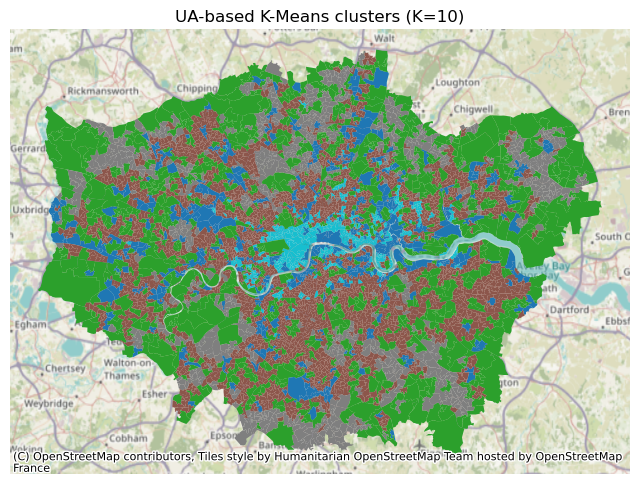

In [28]:
from sklearn.cluster import KMeans

K = 5
km_ua = KMeans(n_clusters=K, random_state=42, n_init=10)
ua_cluster_labels = pandas.Series(
    km_ua.fit_predict(ua_wide_agg),
    index=ua_wide_agg.index,
    name='ua_cluster'
)

ax = (
    emb24[['LSOA21CD', 'geometry']]
    .set_index('LSOA21CD')
    .join(ua_cluster_labels)
    .plot(column='ua_cluster', cmap='tab10', figsize=(8, 8))
)
cx.add_basemap(ax, crs=emb24.crs)
ax.set_axis_off()
ax.set_title('UA-based K-Means clusters (K=10)')

In [29]:
# Join both cluster labels with LSOA areas
both = (
    lsoas[['LSOA21CD', 'lsoa_area']]
    .set_index('LSOA21CD')
    .join(cluster_labels.rename('Embedding cluster'))
    .join(ua_cluster_labels.rename('UA cluster'))
    .dropna()
)
both[['Embedding cluster', 'UA cluster']] = both[['Embedding cluster', 'UA cluster']].astype(int)

# Area (km²) per (embedding cluster × UA cluster)
cross_area = (
    both.groupby(['Embedding cluster', 'UA cluster'])['lsoa_area'].sum()
    .unstack(fill_value=0)
    .div(1e6)
    .round(2)
)

# Row-normalise: fraction of each embedding cluster's area per UA cluster
cross_norm = cross_area.div(cross_area.sum(axis=1), axis=0).round(3)

print("Area (km²) per (embedding cluster × UA cluster)")
display(cross_area.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.2f}'))

print("\nRow-normalised: fraction of each embedding cluster's area across UA clusters")
display(cross_norm.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.3f}'))


Area (km²) per (embedding cluster × UA cluster)


UA cluster,0,1,2,3,4
Embedding cluster,,,,,
0,26.69,84.19,155.19,129.98,0.34
1,25.41,7.29,82.30,4.89,19.29
2,61.41,27.61,81.32,27.36,9.21
3,34.59,6.81,81.69,10.33,13.04
4,12.94,504.11,6.72,67.13,0.12



Row-normalised: fraction of each embedding cluster's area across UA clusters


UA cluster,0,1,2,3,4
Embedding cluster,,,,,
0,0.067,0.212,0.392,0.328,0.001
1,0.183,0.052,0.591,0.035,0.139
2,0.297,0.133,0.393,0.132,0.045
3,0.236,0.046,0.558,0.071,0.089
4,0.022,0.853,0.011,0.114,0.000
